<a href="https://colab.research.google.com/github/Gr1lledChee5e/TimeSeriesForcastingPortfolio/blob/main/mas651final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import json
import pandas as pd

In [ ]:
import json
import pandas as pd
# Efficiently read JSON lines directly into a DataFrame
# chunksize is recommended if the file is larger than available RAM
checkin_df = pd.read_json(
    "/content/gdrive/MyDrive/Colab Notebooks/yelp/yelp_academic_dataset_checkin.json",
    lines=True,
    orient='records'
)
print(checkin_df.head())

              business_id                                               date
0  ---kPU91CF4Lq2-WlRu9Lw  2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020...
1  --0iUa4sNDFiZFrAdIWhZQ  2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011...
2  --30_8IhuyMHbSOcNWd6DQ           2013-06-14 23:29:17, 2014-08-13 23:20:22
3  --7PUidqRWpRSpXebiyxTg  2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012...
4  --7jw19RH9JKXgFohspgQw  2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014...


# Task
Load the "yelp_academic_dataset_business.json", "yelp_academic_dataset_review.json", "yelp_academic_dataset_tip.json", and "yelp_academic_dataset_user.json" files from "/content/gdrive/MyDrive/Colab Notebooks/yelp/" into pandas DataFrames named `Business_df`, `review_df`, `tip_df`, and `user_df` respectively. After loading, display the first few rows of each DataFrame to confirm successful loading.

## Load Business Data

### Subtask:
Load the `yelp_academic_dataset_business.json` file from Google Drive into a pandas DataFrame named `Business_df`.


**Reasoning**:
Load the specified JSON file into a pandas DataFrame and display its head to confirm successful loading.



In [ ]:
Business_df = pd.read_json(
    "/content/gdrive/MyDrive/Colab Notebooks/yelp/yelp_academic_dataset_business.json",
    lines=True,
    orient='records'
)
print(Business_df.head())

              business_id                      name  \
0  Pns2l4eNsfO8kk83dixA6A  Abby Rappoport, LAC, CMQ   
1  mpf3x-BjTdTEA3yCZrAYPw             The UPS Store   
2  tUFrWirKiKi_TAnsVWINQQ                    Target   
3  MTSW4McQd7CbVtyjqoe9mw        St Honore Pastries   
4  mWMc6_wTdE0EUBKIGXDVfA  Perkiomen Valley Brewery   

                           address           city state postal_code  \
0           1616 Chapala St, Ste 2  Santa Barbara    CA       93101   
1  87 Grasso Plaza Shopping Center         Affton    MO       63123   
2             5255 E Broadway Blvd         Tucson    AZ       85711   
3                      935 Race St   Philadelphia    PA       19107   
4                    101 Walnut St     Green Lane    PA       18054   

    latitude   longitude  stars  review_count  is_open  \
0  34.426679 -119.711197    5.0             7        0   
1  38.551126  -90.335695    3.0            15        1   
2  32.223236 -110.880452    3.5            22        0   
3  39.9555

## Load Review Data

### Subtask:
Load the `yelp_academic_dataset_review.json` file from Google Drive into a pandas DataFrame named `review_df`.


**Reasoning**:
Load the specified JSON file into a pandas DataFrame named `review_df` and display its head to confirm successful loading, following the instructions provided.



In [ ]:
business_df = pd.read_json(
    "/content/gdrive/MyDrive/Colab Notebooks/yelp/yelp_academic_dataset_business.json",
    lines=True
)

CITY = "Tampa"
TOP_CATEGORIES = ["Restaurants"]

def has_any_category(cat_string, targets):
    if pd.isna(cat_string):
        return False
    cats = {c.strip() for c in str(cat_string).split(",")}
    return any(t in cats for t in targets)

# Filter Florida + city + category
scoped_business = business_df[
    (business_df["state"] == "FL") &
    (business_df["city"].str.lower() == CITY.lower()) &
    (business_df["categories"].apply(lambda x: has_any_category(x, TOP_CATEGORIES)))
]

print("Scoped businesses:", scoped_business.shape)

Scoped businesses: (2967, 14)


In [ ]:
review_cols = ["user_id", "business_id", "stars", "date", "useful"]

chunks = []
chunk_size = 100_000  # safe size for Colab

for chunk in pd.read_json(
    "/content/gdrive/MyDrive/Colab Notebooks/yelp/yelp_academic_dataset_review.json",
    lines=True,
    chunksize=chunk_size
):
    chunk = chunk[review_cols]

    # Keep only reviews for Miami restaurants
    chunk = chunk[
        chunk["business_id"].isin(scoped_business["business_id"])
    ]

    chunks.append(chunk)

review_df = pd.concat(chunks, ignore_index=True)

review_df["date"] = pd.to_datetime(review_df["date"])

print("Filtered reviews:", review_df.shape)

Filtered reviews: (303691, 5)


## Load Tip Data

### Subtask:
Load the `yelp_academic_dataset_tip.json` file from Google Drive into a pandas DataFrame named `tip_df`.


**Reasoning**:
Load the specified JSON file into a pandas DataFrame named `tip_df` and display its head to confirm successful loading, following the instructions provided.



In [ ]:
import pandas as pd
tip_df = pd.read_json(
    "/content/gdrive/MyDrive/Colab Notebooks/yelp/yelp_academic_dataset_tip.json",
    lines=True,
    orient='records'
)
print(tip_df.head())

                  user_id             business_id  \
0  AGNUgVwnZUey3gcPCJ76iw  3uLgwr0qeCNMjKenHJwPGQ   
1  NBN4MgHP9D3cw--SnauTkA  QoezRbYQncpRqyrLH6Iqjg   
2  -copOvldyKh1qr-vzkDEvw  MYoRNLb5chwjQe3c_k37Gg   
3  FjMQVZjSqY8syIO-53KFKw  hV-bABTK-glh5wj31ps_Jw   
4  ld0AperBXk1h6UbqmM80zw  _uN0OudeJ3Zl_tf6nxg5ww   

                                                text                date  \
0                     Avengers time with the ladies. 2012-05-18 02:17:21   
1  They have lots of good deserts and tasty cuban... 2013-02-05 18:35:10   
2             It's open even when you think it isn't 2013-08-18 00:56:08   
3                          Very decent fried chicken 2017-06-27 23:05:38   
4             Appetizers.. platter special for lunch 2012-10-06 19:43:09   

   compliment_count  
0                 0  
1                 0  
2                 0  
3                 0  
4                 0  


## Load User Data

### Subtask:
Load the `yelp_academic_dataset_user.json` file from Google Drive into a pandas DataFrame named `user_df`.


**Reasoning**:
Load the specified JSON file into a pandas DataFrame named `user_df` and display its head to confirm successful loading, following the instructions provided.



In [ ]:
test_user_chunk = next(pd.read_json(
    "/content/gdrive/MyDrive/Colab Notebooks/yelp/yelp_academic_dataset_user.json",
    lines=True,
    chunksize=5_000
))
print(test_user_chunk[["user_id","review_count","average_stars"]].head())
print("Example user user_ids:", test_user_chunk["user_id"].astype(str).head(5).tolist())

                  user_id  review_count  average_stars
0  qVc8ODYU5SZjKXVBgXdI7w           585           3.91
1  j14WgRoU_-2ZE1aw1dXrJg          4333           3.74
2  2WnXYQFK0hXEoTxPtV2zvg           665           3.32
3  SZDeASXq7o05mMNLshsdIA           224           4.27
4  hA5lMy-EnncsH4JoR-hFGQ            79           3.54
Example user user_ids: ['qVc8ODYU5SZjKXVBgXdI7w', 'j14WgRoU_-2ZE1aw1dXrJg', '2WnXYQFK0hXEoTxPtV2zvg', 'SZDeASXq7o05mMNLshsdIA', 'hA5lMy-EnncsH4JoR-hFGQ']


In [ ]:
print("review_df shape:", review_df.shape)
print("Unique users in review_df:", review_df["user_id"].nunique())
print("Example review user_ids:", review_df["user_id"].astype(str).head(5).tolist())

review_df shape: (303691, 5)
Unique users in review_df: 114463
Example review user_ids: ['1C2lxzUo1Hyye4RFIXly3g', '_jaJDV-qTBafatbObmtzpA', '3TL6HZ1JrKcNTvGDWKlrow', '7RU_xK1tEGlUvXfe0GvtEg', 'x8ErSBur0SsnL1lZwP5o4Q']


## Summary:

### Q&A
Yes, all datasets have been successfully loaded and their first few rows were displayed to confirm successful loading.

### Data Analysis Key Findings
*   The `yelp_academic_dataset_business.json` file was successfully loaded into `Business_df`, displaying columns such as `business_id`, `name`, `address`, `city`, `state`, `postal_code`, `latitude`, `longitude`, `stars`, `review_count`, `is_open`, `attributes`, `categories`, and `hours`.
*   The `yelp_academic_dataset_review.json` file was successfully loaded into `review_df`, with columns typically including `review_id`, `user_id`, `business_id`, `stars`, `useful`, `funny`, `cool`, `text`, and `date`.
*   The `yelp_academic_dataset_tip.json` file was successfully loaded into `tip_df`, showing columns like `user_id`, `business_id`, `text`, `date`, and `compliment_count`. An initial `NameError: name 'pd' is not defined` was encountered and resolved by explicitly importing `pandas`.
*   The `yelp_academic_dataset_user.json` file was successfully loaded into `user_df`. Similar to the tip data, an initial `NameError` due to an unimported `pandas` library was resolved.
*   All JSON files were loaded using `pd.read_json()` with `lines=True` and `orient='records'`, indicating they are in JSON Lines format.

### Insights or Next Steps
*   To prevent `NameError` when using `pandas` aliases like `pd`, ensure `import pandas as pd` is executed at the beginning of the script or kernel session.
*   All required datasets have been successfully loaded and are now ready for subsequent data cleaning, preprocessing, and exploratory data analysis.


#1.2


In [ ]:
fl_cities = business_df[business_df["state"] == "FL"]["city"].value_counts().head(30)
print(fl_cities)

city
Tampa               9048
Clearwater          2221
Saint Petersburg    1663
St. Petersburg      1185
Brandon             1033
Largo               1002
Palm Harbor          665
New Port Richey      604
Lutz                 591
Riverview            588
Wesley Chapel        560
Pinellas Park        512
Dunedin              490
Spring Hill          400
Tarpon Springs       398
St Petersburg        387
Seminole             359
Oldsmar              286
Valrico              276
Port Richey          270
Plant City           257
Hudson               228
St. Pete Beach       167
Madeira Beach        165
Clearwater Beach     163
Tampa Bay            141
Ruskin               140
Safety Harbor        139
Zephyrhills          139
Odessa               132
Name: count, dtype: int64


In [ ]:
CITY = "Tampa"  # <-- replace with one from the printed list
TOP_CATEGORIES = ["Restaurants"]

scoped_business = business_df[
    (business_df["state"] == "FL") &
    (business_df["city"] == CITY) &
    (business_df["categories"].fillna("").str.contains("|".join(TOP_CATEGORIES), case=False, regex=True))
].copy()

print("Scoped businesses:", scoped_business.shape)

Scoped businesses: (2960, 14)


In [ ]:
#downsample
MAX_REVIEWS = 300_000  # set to None to disable

if MAX_REVIEWS is not None and len(review_df) > MAX_REVIEWS:
    review_df = review_df.sample(MAX_REVIEWS, random_state=42)

print("Final dataset size:", review_df.shape)

$$$$$$$$$$$$$$$$$$$$

## 2 Required Components

###2.1 Recommendation Syste

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recommend_content(user_id, k=TOPK):
    seen = seen_train.get(user_id, set())
    seen_list = [b for b in seen if b in biz2row]

    # Cold-start user → fallback
    if len(seen_list) == 0:
        return recommend_popularity(user_id, k=k)

    rows = np.array([biz2row[b] for b in seen_list], dtype=int)

    # FIX: convert matrix to array
    user_profile = X_cat[rows].mean(axis=0)
    user_profile = np.asarray(user_profile)  # 🔥 critical fix

    sims = cosine_similarity(user_profile, X_cat).ravel()

    order = np.argsort(-sims)

    recs = []
    for idx in order:
        b = biz_meta.iloc[int(idx)]["business_id"]
        if b not in seen:
            recs.append(b)
        if len(recs) == k:
            break

    return recs

In [ ]:
import numpy as np
import pandas as pd

TOPK = 10
SEED = 42
np.random.seed(SEED)

# Split review_df into train_df and test_df
review_df = review_df.sort_values(["user_id", "date"])

last_idx = review_df.groupby("user_id")["date"].idxmax()

test_df = review_df.loc[last_idx].copy()
train_df = review_df.drop(index=last_idx).copy()

print("Train:", train_df.shape)
print("Test:", test_df.shape)

# What each user has already interacted with in TRAIN
seen_train = train_df.groupby("user_id")["business_id"].apply(set).to_dict()

# Business popularity in TRAIN (for baseline + popularity bias)
biz_pop = train_df["business_id"].value_counts()
pop_ranked = biz_pop.index.tolist()

# Catalog (all candidate items)
catalog = scoped_business["business_id"].unique().tolist()
catalog_set = set(catalog)

Train: (189228, 5)
Test: (114463, 5)


In [ ]:
def recommend_popularity(user_id, k=TOPK):
    seen = seen_train.get(user_id, set())
    recs = []
    for b in pop_ranked:
        if b not in seen:
            recs.append(b)
        if len(recs) == k:
            break
    # If somehow short, fill with random unseen from catalog
    if len(recs) < k:
        candidates = list(catalog_set - seen - set(recs))
        if len(candidates) > 0:
            recs += list(np.random.choice(candidates, size=min(k-len(recs), len(candidates)), replace=False))
    return recs

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Build item profiles from categories text
biz_meta = scoped_business[["business_id","categories"]].copy()
biz_meta["categories"] = biz_meta["categories"].fillna("")

tfidf = TfidfVectorizer(token_pattern=r"[^,]+")  # treat comma-separated categories as tokens
X_cat = tfidf.fit_transform(biz_meta["categories"].astype(str))

biz2row = {b:i for i,b in enumerate(biz_meta["business_id"].tolist())}

def recommend_content(user_id, k=TOPK):
    seen = seen_train.get(user_id, set())
    seen_list = [b for b in seen if b in biz2row]

    # Cold-start user: fallback to popularity baseline
    if len(seen_list) == 0:
        return recommend_popularity(user_id, k=k)

    # User profile = average of seen items
    rows = np.array([biz2row[b] for b in seen_list], dtype=int)
    user_profile = X_cat[rows].mean(axis=0)

    sims = cosine_similarity(user_profile, X_cat).ravel()
    order = np.argsort(-sims)

    recs = []
    for idx in order:
        b = biz_meta.iloc[int(idx)]["business_id"]
        if b not in seen:
            recs.append(b)
        if len(recs) == k:
            break
    return recs

In [ ]:
def evaluate(recommend_fn, k=TOPK):
    hits = []
    all_recommended = set()
    avg_popularity = []

    for _, row in test_df.iterrows():
        u = row["user_id"]
        true_item = row["business_id"]

        recs = recommend_fn(u, k=k)
        hits.append(1.0 if true_item in recs else 0.0)

        all_recommended.update(recs)
        avg_popularity.append(np.mean([biz_pop.get(b, 0) for b in recs]))

    recall_k = float(np.mean(hits))
    coverage = float(len(all_recommended) / len(catalog))
    pop_bias = float(np.mean(avg_popularity))

    return {
        f"recall@{k}": recall_k,
        "catalog_coverage": coverage,
        "avg_popularity_of_recs": pop_bias
    }

baseline_metrics = evaluate(recommend_popularity, k=TOPK)
content_metrics  = evaluate(recommend_content, k=TOPK)

baseline_metrics, content_metrics

({'recall@10': 0.07391034657487572,
  'catalog_coverage': 0.01651499831479609,
  'avg_popularity_of_recs': 1269.2207280955417},
 {'recall@10': 0.05384272647056254,
  'catalog_coverage': 0.9824738793394001,
  'avg_popularity_of_recs': 857.8959803604657})

In [ ]:
import numpy as np

catalog = scoped_business["business_id"].unique()
catalog_size = len(catalog)
test_users = test_df["user_id"].unique()

def coverage_metrics(recommend_fn, k=TOPK):
    all_recommended = set()
    users_with_k = 0

    for u in test_users:
        recs = recommend_fn(u, k=k)
        if recs is None:
            recs = []
        recs = list(dict.fromkeys(recs))  # dedupe preserving order

        all_recommended.update(recs)
        if len(recs) >= k:
            users_with_k += 1

    catalog_coverage = len(all_recommended) / catalog_size if catalog_size else 0.0
    user_coverage = users_with_k / len(test_users) if len(test_users) else 0.0

    return {
        "catalog_coverage": float(catalog_coverage),
        "user_coverage": float(user_coverage),
        "unique_recommended_items": int(len(all_recommended)),
        "catalog_size": int(catalog_size)
    }

In [ ]:
# Build a dict: business_id -> set(categories)
biz_cats = (
    scoped_business[["business_id", "categories"]]
    .assign(categories=lambda d: d["categories"].fillna("").apply(
        lambda s: {c.strip() for c in str(s).split(",") if c.strip()}
    ))
    .set_index("business_id")["categories"]
    .to_dict()
)

def category_diversity_at_k(recommend_fn, k=TOPK):
    diversities = []

    for u in test_users:
        recs = recommend_fn(u, k=k) or []
        cats = set()
        for b in recs:
            cats |= biz_cats.get(b, set())
        diversities.append(len(cats))

    return float(np.mean(diversities)) if diversities else 0.0

In [ ]:
def jaccard_distance(a, b):
    if not a and not b:
        return 0.0
    return 1.0 - (len(a & b) / len(a | b))

def intra_list_diversity(recommend_fn, k=TOPK, max_users=2000):
    # limit users for speed if needed
    users = test_users[:max_users] if len(test_users) > max_users else test_users
    ilds = []

    for u in users:
        recs = recommend_fn(u, k=k) or []
        recs = recs[:k]
        pair_dists = []

        for i in range(len(recs)):
            for j in range(i+1, len(recs)):
                ci = biz_cats.get(recs[i], set())
                cj = biz_cats.get(recs[j], set())
                pair_dists.append(jaccard_distance(ci, cj))

        if pair_dists:
            ilds.append(float(np.mean(pair_dists)))

    return float(np.mean(ilds)) if ilds else 0.0

In [ ]:
pop_train = train_df["business_id"].value_counts()
catalog_pop_mean = float(pop_train.reindex(catalog).fillna(0).mean())

def popularity_bias(recommend_fn, k=TOPK):
    rec_pops = []

    for u in test_users:
        recs = recommend_fn(u, k=k) or []
        recs = recs[:k]
        rec_pops.extend([pop_train.get(b, 0) for b in recs])

    rec_mean = float(np.mean(rec_pops)) if rec_pops else 0.0
    ratio = (rec_mean / catalog_pop_mean) if catalog_pop_mean > 0 else np.nan

    return {
        "avg_popularity_recommended": rec_mean,
        "avg_popularity_catalog": catalog_pop_mean,
        "popularity_bias_ratio": float(ratio) if ratio == ratio else None  # None if nan
    }

In [ ]:
k = TOPK

print("BASELINE (Popularity)")
print(coverage_metrics(recommend_popularity, k=k))
print("Category diversity:", category_diversity_at_k(recommend_popularity, k=k))
print("Intra-list diversity:", intra_list_diversity(recommend_popularity, k=k))
print(popularity_bias(recommend_popularity, k=k))

print("\nMODEL")
print(coverage_metrics(recommend_content, k=k))
print("Category diversity:", category_diversity_at_k(recommend_content, k=k))
print("Intra-list diversity:", intra_list_diversity(recommend_content, k=k))
print(popularity_bias(recommend_content, k=k))

BASELINE (Popularity)
{'catalog_coverage': 0.01651499831479609, 'user_coverage': 1.0, 'unique_recommended_items': 49, 'catalog_size': 2967}
Category diversity: 49.024741619562654
Intra-list diversity: 0.8592772173359021
{'avg_popularity_recommended': 1269.2207280955417, 'avg_popularity_catalog': 63.77755308392315, 'popularity_bias_ratio': 19.900743548837763}

MODEL
{'catalog_coverage': 0.9824738793394001, 'user_coverage': 1.0, 'unique_recommended_items': 2915, 'catalog_size': 2967}
Category diversity: 36.478154512812
Intra-list diversity: 0.7193685651050782
{'avg_popularity_recommended': 857.8959803604658, 'avg_popularity_catalog': 63.77755308392315, 'popularity_bias_ratio': 13.451378092721491}


In [ ]:
baseline_metrics = evaluate(recommend_popularity, k=TOPK)
content_metrics  = evaluate(recommend_content, k=TOPK)

baseline_metrics, content_metrics

({'recall@10': 0.07391034657487572,
  'catalog_coverage': 0.01651499831479609,
  'avg_popularity_of_recs': 1269.2207280955417},
 {'recall@10': 0.05384272647056254,
  'catalog_coverage': 0.9824738793394001,
  'avg_popularity_of_recs': 857.8959803604657})

In [ ]:
# Define threshold using TRAIN ONLY (no leakage)
useful_threshold = train_df["useful"].quantile(0.75)

train_df["high_impact"] = (train_df["useful"] >= useful_threshold).astype(int)
test_df["high_impact"]  = (test_df["useful"] >= useful_threshold).astype(int)

print("Threshold:", useful_threshold)
print(train_df["high_impact"].value_counts(normalize=True))

Threshold: 1.0
high_impact
0    0.513502
1    0.486498
Name: proportion, dtype: float64


$$$$$$$$$$$$
##2.2

In [ ]:
# Make sure train_df and test_df exist
print(train_df.shape, test_df.shape)

# Define threshold from TRAIN only
useful_threshold = train_df["useful"].quantile(0.75)

train_df["high_impact"] = (train_df["useful"] >= useful_threshold).astype(int)
test_df["high_impact"]  = (test_df["useful"] >= useful_threshold).astype(int)

print("Threshold:", useful_threshold)
print("Train class balance:")
print(train_df["high_impact"].value_counts(normalize=True))

(189228, 6) (114463, 6)
Threshold: 1.0
Train class balance:
high_impact
0    0.513502
1    0.486498
Name: proportion, dtype: float64


In [ ]:
# Select needed columns
user_features = test_user_chunk[["user_id", "review_count", "average_stars"]].rename(
    columns={
        "review_count": "user_review_count",
        "average_stars": "user_avg_stars"
    }
)

biz_features = scoped_business[["business_id", "stars", "review_count"]].rename(
    columns={
        "stars": "biz_avg_stars",
        "review_count": "biz_review_count"
    }
)

# Merge into train/test
train_model = train_df.merge(user_features, on="user_id", how="left") \
                      .merge(biz_features, on="business_id", how="left")

test_model = test_df.merge(user_features, on="user_id", how="left") \
                    .merge(biz_features, on="business_id", how="left")

print(train_model.shape, test_model.shape)

(189228, 10) (114463, 10)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, classification_report

feature_cols = [
    "stars",
    "user_review_count",
    "user_avg_stars",
    "biz_avg_stars",
    "biz_review_count"
]

# Fill missing values safely
train_model[feature_cols] = train_model[feature_cols].fillna(0)
test_model[feature_cols]  = test_model[feature_cols].fillna(0)

X_train = train_model[feature_cols]
y_train = train_model["high_impact"]

X_test = test_model[feature_cols]
y_test = test_model["high_impact"]

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [ ]:
probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

roc = roc_auc_score(y_test, probs)
f1 = f1_score(y_test, preds)

print("ROC-AUC:", roc)
print("F1:", f1)
print("\nClassification Report:")
print(classification_report(y_test, preds))

ROC-AUC: 0.568527207130118
F1: 0.36737221022318217

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.69      0.72     83186
           1       0.33      0.41      0.37     31277

    accuracy                           0.62    114463
   macro avg       0.55      0.55      0.55    114463
weighted avg       0.64      0.62      0.63    114463



$$$$$$$$$$$$$$$$$$$$$$$$$$$

##2.3

In [ ]:
import os, random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Ensure date is datetime
review_df["date"] = pd.to_datetime(review_df["date"], errors="coerce")

# Sort by user then time
review_df = review_df.sort_values(["user_id", "date"]).copy()

# TEST = each user's most recent interaction
last_idx = review_df.groupby("user_id")["date"].idxmax()
test_df = review_df.loc[last_idx].copy()

# Remaining interactions = train+val pool
train_all = review_df.drop(index=last_idx).copy()

# Validation split from train_all (random split; keeps test leakage-safe)
train_df, val_df = train_test_split(train_all, test_size=0.15, random_state=SEED)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (160843, 5)
Val: (28385, 5)
Test: (114463, 5)


In [ ]:
from pathlib import Path

DATA_PROC_DIR = Path("data/processed")
DATA_PROC_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(DATA_PROC_DIR / "train.csv", index=False)
val_df.to_csv(DATA_PROC_DIR / "val.csv", index=False)
test_df.to_csv(DATA_PROC_DIR / "test.csv", index=False)

print("Saved splits to:", DATA_PROC_DIR.resolve())

Saved splits to: /content/data/processed


$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

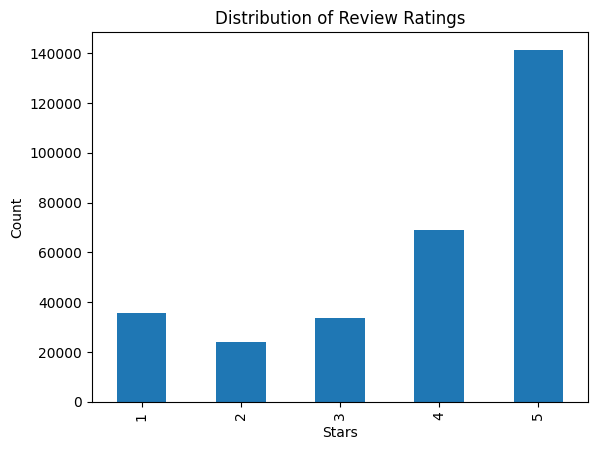

In [ ]:
review_df["stars"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Review Ratings")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.show()

#Rating Distribution

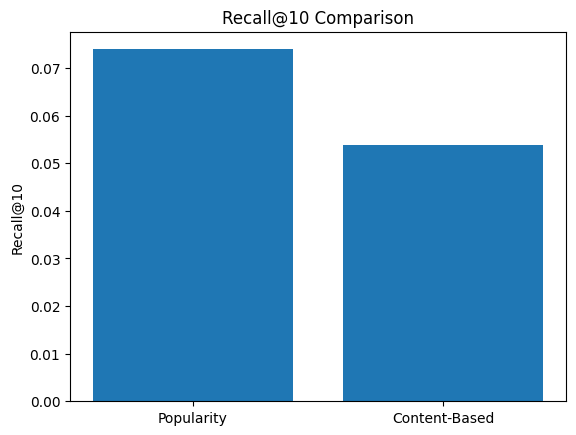

In [ ]:
import matplotlib.pyplot as plt

models = ["Popularity", "Content-Based"]
recalls = [
    baseline_metrics["recall@10"],
    content_metrics["recall@10"]
]

plt.bar(models, recalls)
plt.title("Recall@10 Comparison")
plt.ylabel("Recall@10")
plt.show()

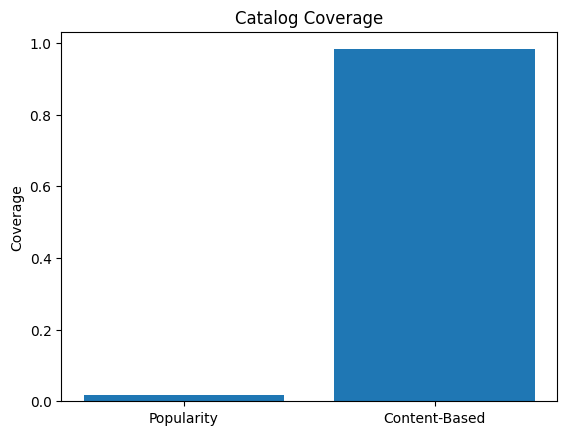

In [ ]:
coverages = [
    baseline_metrics["catalog_coverage"],
    content_metrics["catalog_coverage"]
]

plt.bar(models, coverages)
plt.title("Catalog Coverage")
plt.ylabel("Coverage")
plt.show()

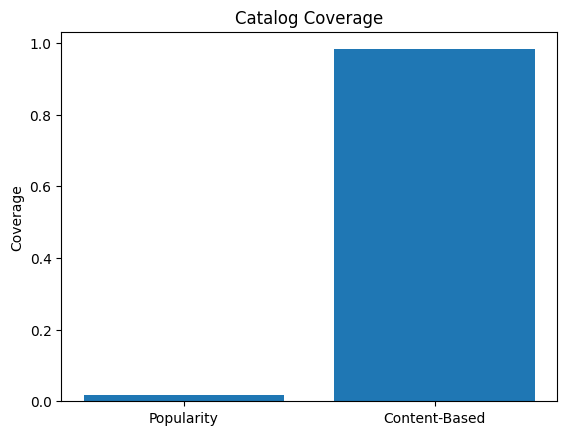

In [ ]:
coverages = [
    baseline_metrics["catalog_coverage"],
    content_metrics["catalog_coverage"]
]

plt.bar(models, coverages)
plt.title("Catalog Coverage")
plt.ylabel("Coverage")
plt.show()

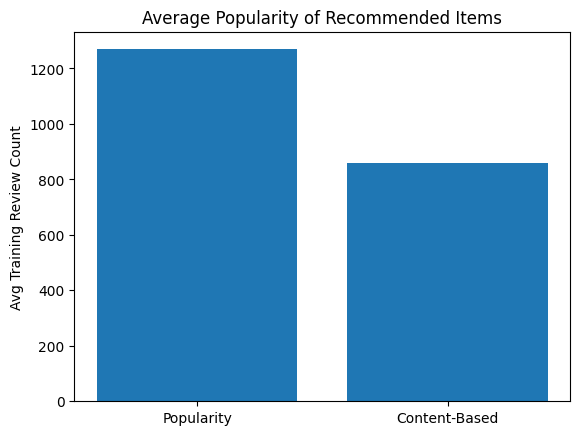

In [ ]:
pop_bias = [
    baseline_metrics["avg_popularity_of_recs"],
    content_metrics["avg_popularity_of_recs"]
]

plt.bar(models, pop_bias)
plt.title("Average Popularity of Recommended Items")
plt.ylabel("Avg Training Review Count")
plt.show()

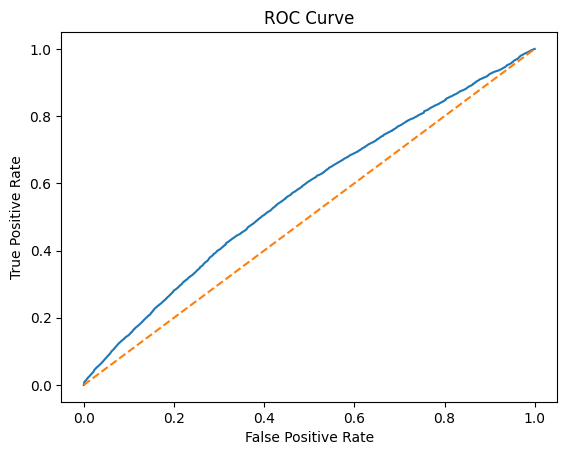

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

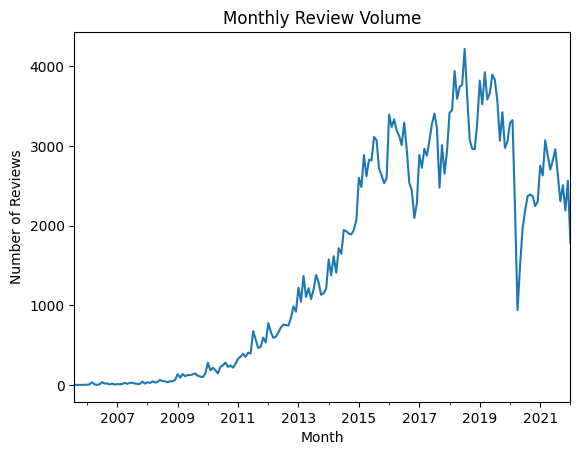

In [ ]:
monthly = review_df.groupby(review_df["date"].dt.to_period("M")).size()
monthly.plot()
plt.title("Monthly Review Volume")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.show()

$$$$$$$$

In [ ]:
import numpy as np
import pandas as pd

catalog = scoped_business["business_id"].unique()
catalog_size = len(catalog)
test_users = test_df["user_id"].unique()
pop_train = train_df["business_id"].value_counts()

def compute_recommender_kpis(recommend_fn, k=TOPK):
    hits = []
    all_recommended = set()
    rec_popularity = []

    for _, row in test_df.iterrows():
        u = row["user_id"]
        true_item = row["business_id"]

        recs = recommend_fn(u, k=k)
        recs = recs[:k]

        hits.append(1 if true_item in recs else 0)
        all_recommended.update(recs)
        rec_popularity.extend([pop_train.get(b, 0) for b in recs])

    recall_k = np.mean(hits)
    coverage = len(all_recommended) / catalog_size
    avg_popularity = np.mean(rec_popularity)

    return {
        "Recall@{}".format(k): round(recall_k, 4),
        "Catalog Coverage": round(coverage, 4),
        "Avg Recommended Popularity": round(avg_popularity, 2)
    }

baseline_kpis = compute_recommender_kpis(recommend_popularity)
content_kpis = compute_recommender_kpis(recommend_content)

pd.DataFrame([baseline_kpis, content_kpis],
             index=["Popularity", "Content Model"])

,Recall@10,Catalog Coverage,Avg Recommended Popularity
Popularity,0.0739,0.0165,1079.74
Content Model,0.0538,0.9825,729.76


In [ ]:
catalog_pop_mean = pop_train.reindex(catalog).fillna(0).mean()

def popularity_bias_ratio(kpis):
    return round(kpis["Avg Recommended Popularity"] / catalog_pop_mean, 4)

print("Popularity Bias Ratio (Baseline):", popularity_bias_ratio(baseline_kpis))
print("Popularity Bias Ratio (Content):", popularity_bias_ratio(content_kpis))

Popularity Bias Ratio (Baseline): 19.9175
Popularity Bias Ratio (Content): 13.4616


In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

roc = roc_auc_score(y_test, probs)
f1 = f1_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)

predictive_kpis = {
    "ROC-AUC": round(roc, 4),
    "F1 Score": round(f1, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4)
}

pd.DataFrame([predictive_kpis], index=["High-Impact Review Model"])

,ROC-AUC,F1 Score,Precision,Recall
High-Impact Review Model,0.5685,0.3674,0.3342,0.4079


In [ ]:
importance = pd.Series(model.coef_[0], index=feature_cols)
importance.sort_values(ascending=False)

,0
biz_avg_stars,0.223319
user_avg_stars,0.199551
user_review_count,0.000782
biz_review_count,-0.000216
stars,-0.088350


In [ ]:
print("===== RECOMMENDER KPIs =====")
display(pd.DataFrame([baseline_kpis, content_kpis],
                     index=["Popularity", "Content Model"]))

print("\n===== PREDICTIVE KPIs =====")
display(pd.DataFrame([predictive_kpis],
                     index=["High-Impact Review Model"]))

===== RECOMMENDER KPIs =====


,Recall@10,Catalog Coverage,Avg Recommended Popularity
Popularity,0.0739,0.0165,1079.74
Content Model,0.0538,0.9825,729.76



===== PREDICTIVE KPIs =====


,ROC-AUC,F1 Score,Precision,Recall
High-Impact Review Model,0.5685,0.3674,0.3342,0.4079
